# 기본 셋팅

In [1]:
# ==========================================================
# 1. Import Library
# ==========================================================
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data Split & Hyperparameter Tuning
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

# Scaling
from sklearn.preprocessing import MinMaxScaler

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

# Imbalanced Data
from imblearn.over_sampling import SMOTE

# Random Forest
from sklearn.ensemble import RandomForestClassifier

# ==========================================================
# 2. Load Dataset
# ==========================================================

df = pd.read_csv("ai4i2020.csv")

# 컬럼명 공백 제거
df.columns = df.columns.str.strip()

print("=" * 60)
print("Dataset Shape")
print("=" * 60)
print(df.shape)

print()

print("=" * 60)
print("Dataset Information")
print("=" * 60)
print(df.info())

print()

print("=" * 60)
print("Machine Failure Distribution")
print("=" * 60)
print(df["Machine failure"].value_counts())

display(df.head())

Dataset Shape
(10000, 14)

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
# ==========================================================
# 3. Preprocessing
# ==========================================================

# Product ID 제거
df = df.drop(columns=["Product ID"])

# Type One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=["Type"],
    drop_first=True
)

# Feature / Target
X = df.drop(columns=[
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
])

y = df["Machine failure"]

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=49,

    stratify=y

)

# Scaling
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SMOTE
sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(
    X_train,
    y_train
)

print("=" * 60)
print("Train Shape")
print("=" * 60)
print(X_train.shape)

print()

print("=" * 60)
print("After SMOTE")
print("=" * 60)
print(pd.Series(y_train_sm).value_counts())

Train Shape
(8000, 8)

After SMOTE
Machine failure
0    7729
1    7729
Name: count, dtype: int64


In [3]:
# ==========================================================
# 4. Result Function
# ==========================================================

results = []

def evaluate_model(model_name, model, X_test, y_test, threshold=0.3):

    proba = model.predict_proba(X_test)

    pred = (proba[:,1] > threshold).astype(int)

    acc = accuracy_score(y_test, pred)
    pre = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(classification_report(y_test, pred))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred
    )

    plt.title(model_name)
    plt.show()

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": pre,
        "Recall": rec,
        "F1-score": f1
    })

# Hyperparameter

[LightGBM] [Info] Number of positive: 7729, number of negative: 7729
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000362 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1531
[LightGBM] [Info] Number of data points in the train set: 15458, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM - Base
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.67      0.79      0.72        68

    accuracy                           0.98      2000
   macro avg       0.83      0.89      0.86      2000
weighted avg       0.98      0.98      0.98      2000



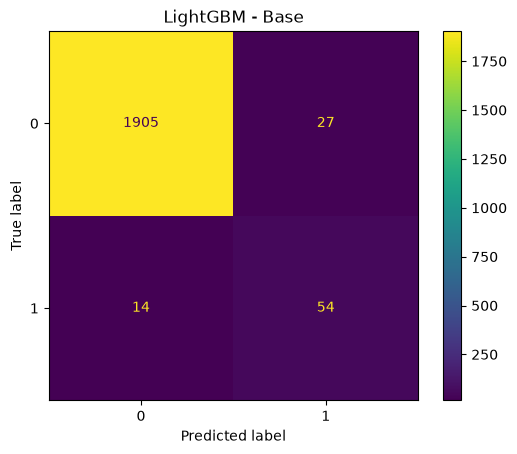

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 6183, number of negative: 6183
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000151 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1532
[LightGBM] [Info] Number of data points in the train set: 12366, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 6183, number of negative: 6183
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000139 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1531
[LightGBM] [Info] Number of data points in the train set: 12366, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 6183, number of negative: 61

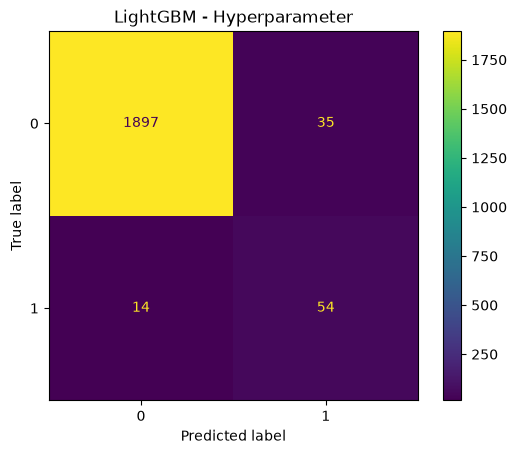

In [4]:
# ==========================================================
# 5. LightGBM - Base Model
# ==========================================================

lgbm_base = LGBMClassifier(

    random_state=42,

    n_estimators=300

)

lgbm_base.fit(
    X_train_sm,
    y_train_sm
)

evaluate_model(

    "LightGBM - Base",

    lgbm_base,

    X_test,

    y_test

)

# ==========================================================
# 6. LightGBM - Hyperparameter
# ==========================================================

param_dist = {

    "n_estimators":[100,200,300,500],

    "learning_rate":[0.01,0.03,0.05,0.1],

    "max_depth":[5,10,15,-1],

    "num_leaves":[31,63,127],

    "min_child_samples":[10,20,30]

}

lgbm_random = RandomizedSearchCV(

    estimator=LGBMClassifier(

        random_state=42

    ),

    param_distributions=param_dist,

    n_iter=20,

    scoring="recall",

    cv=5,

    random_state=42,

    verbose=1,

    n_jobs=1

)

lgbm_random.fit(
    X_train_sm,
    y_train_sm
)

print("="*60)
print("Best Parameter")
print("="*60)

print(
    lgbm_random.best_params_
)

lgbm_best = lgbm_random.best_estimator_

evaluate_model(

    "LightGBM - Hyperparameter",

    lgbm_best,

    X_test,

    y_test

)

# Feature Engineering

[LightGBM] [Info] Number of positive: 7729, number of negative: 7729
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000204 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1531
[LightGBM] [Info] Number of data points in the train set: 15458, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM - Feature
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.67      0.79      0.72        68

    accuracy                           0.98      2000
   macro avg       0.83      0.89      0.86      2000
weighted avg       0.98      0.98      0.98      2000



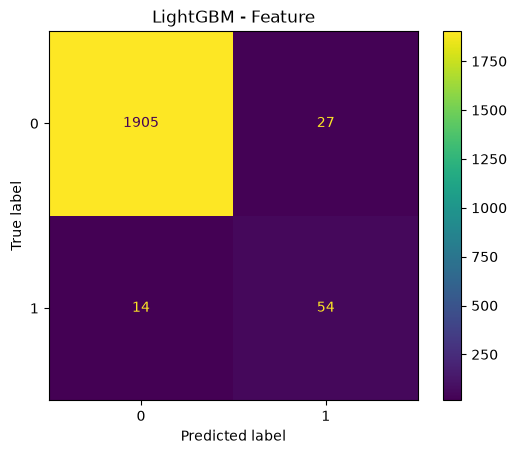

In [5]:
lgbm_feature = LGBMClassifier(

    random_state=42,

    n_estimators=300

)

lgbm_feature.fit(
    X_train_sm,
    y_train_sm
)

evaluate_model(

    "LightGBM - Feature",

    lgbm_feature,

    X_test,

    y_test

)

# Feature + Hyperparameter

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 6183, number of negative: 6183
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000163 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1532
[LightGBM] [Info] Number of data points in the train set: 12366, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 6183, number of negative: 6183
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000169 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1531
[LightGBM] [Info] Number of data points in the train set: 12366, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 6183, number of negative: 61

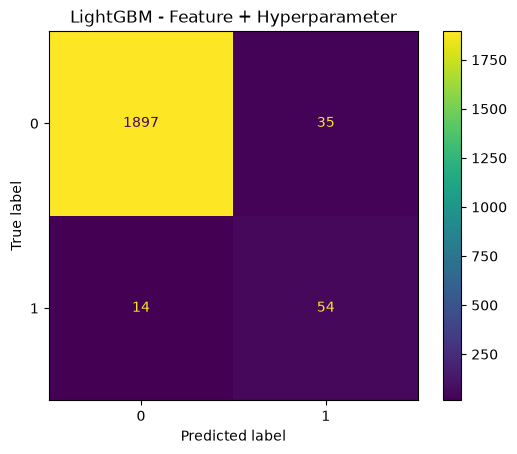

In [6]:
# ==========================================================
# 8. Feature + Hyperparameter
# ==========================================================

lgbm_random.fit(
    X_train_sm,
    y_train_sm
)

print("="*60)
print("Best Parameter")
print("="*60)

print(
    lgbm_random.best_params_
)

lgbm_feature_best = lgbm_random.best_estimator_

evaluate_model(

    "LightGBM - Feature + Hyperparameter",

    lgbm_feature_best,

    X_test,

    y_test

)

# Feature Importance + Result

In [7]:
# ==========================================================
# 9. Result
# ==========================================================

result_df = pd.DataFrame(results)

print("="*60)
print("Result Comparison")
print("="*60)

display(result_df)

print()

print("="*60)
print("Best Model")
print("="*60)

display(
    result_df.sort_values(
        by="F1-score",
        ascending=False
    )
)

Result Comparison


,Model,Accuracy,Precision,Recall,F1-score
0,LightGBM - Base,0.9795,0.666667,0.794118,0.724832
1,LightGBM - Hyperparameter,0.9755,0.606742,0.794118,0.687898
2,LightGBM - Feature,0.9795,0.666667,0.794118,0.724832
3,LightGBM - Feature + Hyperparameter,0.9755,0.606742,0.794118,0.687898



Best Model


,Model,Accuracy,Precision,Recall,F1-score
0,LightGBM - Base,0.9795,0.666667,0.794118,0.724832
2,LightGBM - Feature,0.9795,0.666667,0.794118,0.724832
1,LightGBM - Hyperparameter,0.9755,0.606742,0.794118,0.687898
3,LightGBM - Feature + Hyperparameter,0.9755,0.606742,0.794118,0.687898
